## **Pulsar Timing to Discover Exoplanets Collated Results Group 4a** ##

#### **Notices [READ ME]** ####
Collapse subsections for better use and easier readability.

1.   Add the bits of code and text you did so that the data/figures are readily available for everyone
2.   Keep within the sections/ sub-sections and add any appropiately if you think it belongs elsewhere [The number of hastags in the title determines the sub in section]
3.   Explain code where you can to help others, try and reference papers for any calculations or data
4.   Only one person can work on the file at one time as doesn't work like the rest of the google applications, so let others know when you're working on it so everyones changes can be saved
5. Run the code systematically as data out putted will depend on the pulsar defined, so make sure the correct files are labelled and that the data is based off the corrcet file


#### **What's included?** ####

*  Packages to run the data [mainly libstempo] + (Add correct files with names when running)
*  Code of fake pulsar as a tutorial found on github to experiment with libstempo
*  Actual plot of data, including phase folded and wrap around correction
*  Scipy optimisation of singular day and whole data for rough estimate
*  Least squares optimisation for best optimation phase fold
* Derivation of Pulsar properties
* Derivation of Planet propeties

---
### **Importing Packages** ###

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install_mambaforge()

!mamba install -y -c conda-forge enterprise-pulsar


Mambaforge has been sunset. It is now identical to Miniforge. Installing Miniforge...


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...

Looking for: ['enterprise-pulsar']

[+] 0.0s
conda-forge/linux-64  ⣾  [+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch     1%[+] 0.2s
conda-forge/linux-64   1%
conda-forge/noarch     3%[+] 0.3s
conda-forge/linux-64   2%
conda-forge/noarch    20%[+] 0.4s
conda-forge/linux-64   6%
conda-forge/noarch    42%[+] 0.5s
conda-forge/linux-64  10%
conda-forge/noarch    51%[+] 0.6s
conda-forge/linux-64  13%
conda-forge/noarch    59%[+] 0.7s
conda-forge/linux-64  17%
conda-forge/noarch    68%[+] 0.8s
conda-forge/linux-64  19%
conda-forge/noarch    71%[+] 0.9s
conda-forge/linux-64  21%
conda-forge/noarch    76%[+] 1.0s
conda-forge/linux-64  26%
conda-forge/noarch    89%[+] 1.1s
conda-forge/linux-64  31%
conda-forge/noarch    95%conda-forge/noarch 

In [ ]:
#just in case you get an error about binary incompatibility

!pip uninstall scikit-sparse
!pip install scikit-sparse
from scipy.optimize import curve_fit

Found existing installation: scikit-sparse 0.4.14
Uninstalling scikit-sparse-0.4.14:
  Would remove:
    /usr/local/lib/python3.11/site-packages/scikit_sparse-0.4.14.dist-info/*
    /usr/local/lib/python3.11/site-packages/sksparse/*
Proceed (Y/n)? Y
  Successfully uninstalled scikit-sparse-0.4.14
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for scikit-sparse (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for scikit-sparse
Failed to build scikit-sparse
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (scikit-sparse)


In [ ]:
# Useful imports
%matplotlib inline
import numpy as np
from matplotlib.pyplot import *
import matplotlib.pyplot as plt
import pandas as pd
import libstempo as T
import libstempo.plot as LP
import libstempo.toasim as LT

ModuleNotFoundError: No module named 'libstempo'

---
### **Tutorial of libstempo** ###

**Don't need to run unless needed**

par_writer() creates a .par file which outlines the parameters of the pulsar such as period, posistion relative to us and its movement.

tim_writer() and make_pulsar() creates a .tim file these replicate the time of arrival data based on the .par file

In [ ]:
def par_writer(string,basename='mytiming'):
    output = """MODE 1
PSR      Example Pulsar
PEPOCH    50000.0
"""
    output += string
    with open(basename+".par",'w') as FILE:
        FILE.write(output)
def tim_writer(basename="mytiming"):
    psr = LT.fakepulsar(parfile=basename+".par",
                        obstimes=np.arange(53000,56000,14.0)+np.random.normal(0,1),  # observe every 14+-1 days
                        toaerr=0.1) #toaerr gives the error bars

    LT.add_efac(psr,efac=1.0,seed=1234) #adds the corresponding scatter (multiplied by 1)
    psr.savetim(basename+".tim")

In [ ]:
par_writer("""
F0       66.66666667
""")
tim_writer()

In [ ]:
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
LP.plotres(psr)

In [ ]:
par_writer("""
F0       66.66666666
""")   ## We changed out frequency ever so slightly
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
LP.plotres(psr)

## This is not a good fit as out residuals are much further apart, not a good timing model.

In [ ]:
par_writer("""
F0       66.666666671   1
""")
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
psr.fit()
LP.plotres(psr)

### Here we add the value 1 telling the funtion psr.fit() that we want to fit for the parameter
print(psr['F0'])
### This gives us the parameter that was fitted by the function

In [ ]:
par_writer("""
F0       66.66666667
F1      -1e-19
""")
tim_writer()
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
LP.plotres(psr)

In [ ]:
par_writer("""
F0       66.66666667 1
F1       -1.0e-19 1
""")
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
psr.fit()
LP.plotres(psr)
print(psr['F0'])
print(psr['F1'])

## Once again we are fitting for the frequency and frequency derivative

In [ ]:
par_writer("""
F0       66.66666667
F1      -1e-19
RAJ       19:09:00
DECJ       -37:44:00
""")
tim_writer()
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
LP.plotres(psr)

## for this we added the right ascension and declination aka the position of the puslar in the sky

In [ ]:
par_writer("""
F0       66.66666667
F1      -1e-19
RAJ       19:09:00
DECJ       -37:44:00.001
""")
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
LP.plotres(psr)

dates = psr.toas()
residuals = psr.residuals()
errs = psr.toaerrs
print(errs)
matplotlib.pyplot.plot(dates, residuals)
#matplotlib.pyplot.errorbar(dates, residuals, xerr = None, yerr = errs)
matplotlib.pyplot.show()

## some useful functions

In [ ]:
par_writer("""
F0    66.66666667       1
F1    -1.1e-19             1
RAJ     19:09:00         1
DECJ    -37:44:00.001     1
""")
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
psr.fit()
for parameter in ['F0','F1','RAJ','DECJ']:
    print(psr[parameter])
LP.plotres(psr)

## Finally fitting for all the parameters

In [ ]:
del psr
par_writer("""
F0       66.66666667
F1      -1e-19
RAJ       19:09:00
DECJ       -37:44:00
PX       2
""")
tim_writer()

psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")

par_writer("""
F0       66.66666667
F1      -1e-19
RAJ       19:09:00
DECJ       -37:44:00
PX       2.5
""")

psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
LP.plotres(psr)

In [ ]:
par_writer("""
F0       66.66666667
F1      -1e-19
RAJ       19:09:00
DECJ       -37:44:00
PX       2
PMRA       50.1 1
PMDEC       0.0 1
""")
psr = T.tempopulsar(parfile='mytiming.par',timfile="mytiming.tim")
psr.fit()
LP.plotres(psr)

At last we have fits for a lot of the values including the proper motion along the coordinate system and parallax which is also accounting for the spin dynamics.#

We can move on to calcuate some basic facts about the pulsar such as the energy lost and the surface magnetic field by the equations:

$\dot{E} = 4π^2 I \dot{P} P^{-3} \approx 3.95×10^{31} erg s^{-1}(\frac{\dot{P}}{10^{-15}})(\frac{P}{s})^3$  
$B_s = 3.2×10^{19} G \sqrt{P\dot{P}} \approx 10^{12}G(\frac{\dot{P}}{10^{-15}})^{0.5}(\frac{P}{s})^{0.5}$

In [ ]:
P = 1/66.66666667
F = 66.66666667
Fdot = -1e-19
Pdot = -Fdot /F**2
print(Pdot) #rev/s
Edot = 3.95 * 10 ** 31 * (Pdot /10**-15) * (P)**-3
L_sun = 4*10**33
print(L_sun/Edot) #Several orders of magnitude less than sun

In [ ]:
Bs = (10**(12)) * (Pdot / 10**(-15))**.5 * P**.5
print(f"{Bs} Gauss" )

---

### **Working with Actual Data** ####

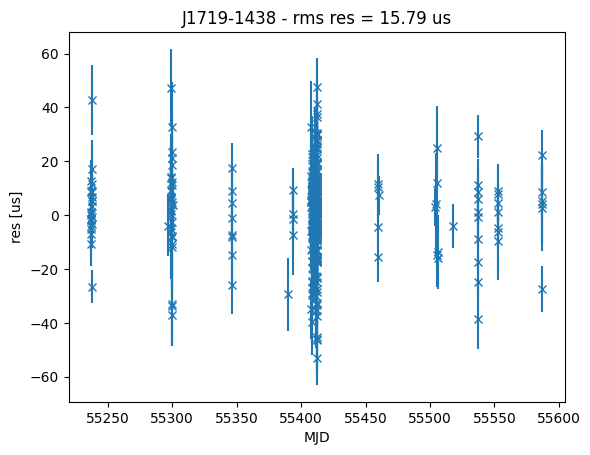

In [ ]:
## Plotting our actual data from the supporting files ##

psractual = T.tempopulsar(parfile='1208890supporting.par',timfile="1208890supporting.tim")

LP.plotres(psractual)

## This plot shows all the data on the files for our plusar, each cross is a singular data point, and each line is the the error bar for each corresponding residual

---
#### **Proving the exisitence of the Planet** ####
* Phase Folding and Timing Model correction

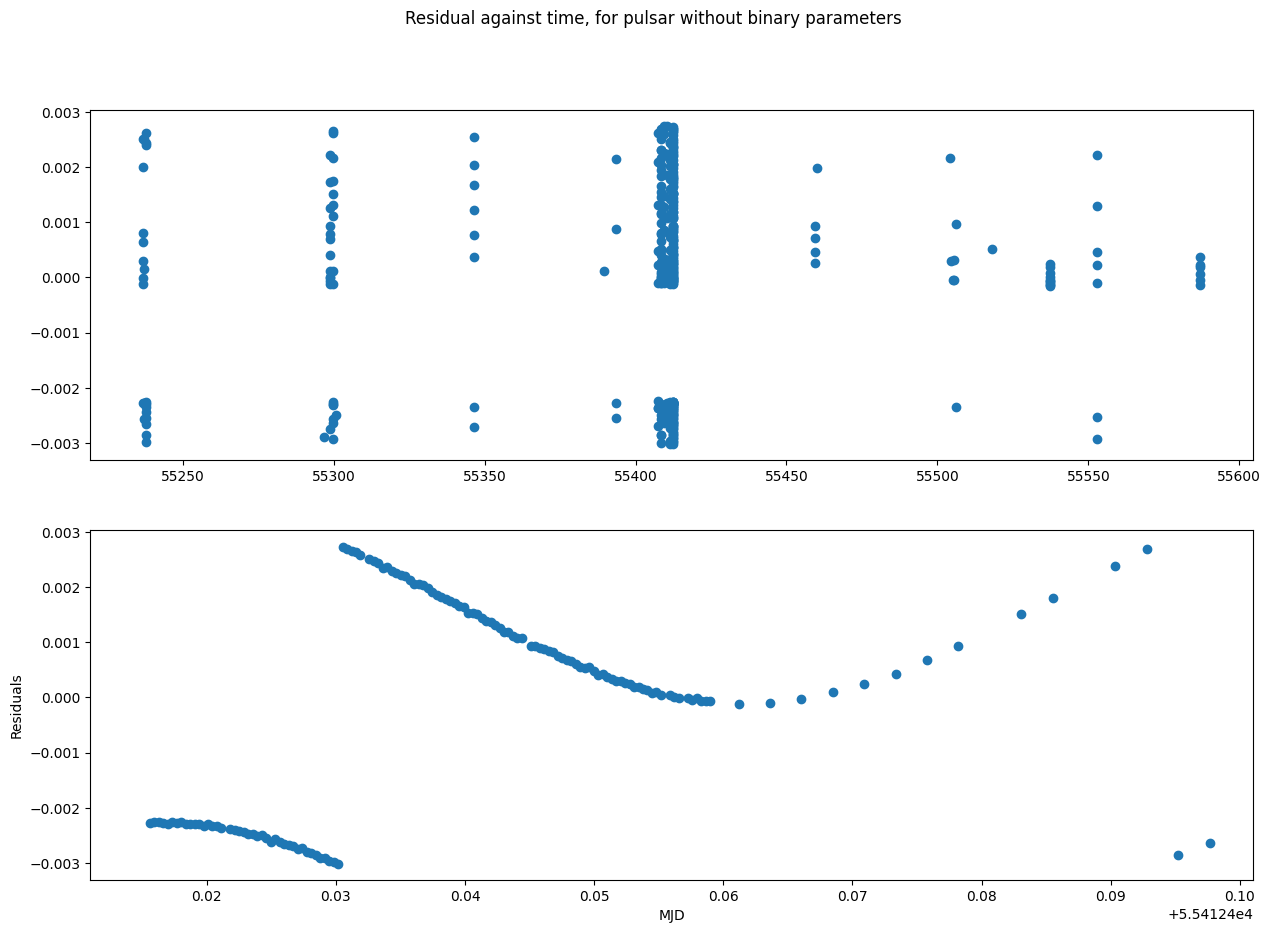

In [ ]:
## Showing the data using pyplots without the binary parameters ##
psr = T.tempopulsar(parfile='1208890supporting - Copy.par',timfile="1208890supporting.tim")

fig, (ax1, ax2) = plt.subplots(2, figsize = (15,10))
fig.suptitle('Residual against time, for pulsar without binary parameters')



ax1.scatter(psr.toas(),psr.residuals())    ## Showing all the data in pyplots
plt.xlabel("MJD")
plt.ylabel("Residuals")
plt.axvline(55412, color = 'red')
plt.axvline(55413, color = 'red')


ax2.scatter(psr.toas(),psr.residuals())  ## Showing just the zoomed in data for the one day showing the motion
plt.xlim(55412.411, 55412.501)
plt.xlabel("MJD")
plt.ylabel("Residuals")

plt.show()

tempo2 parameter F0 (fitted): np.longdouble('172.70704460192937908') +/- np.longdouble('1.9088425373999999946e-10')


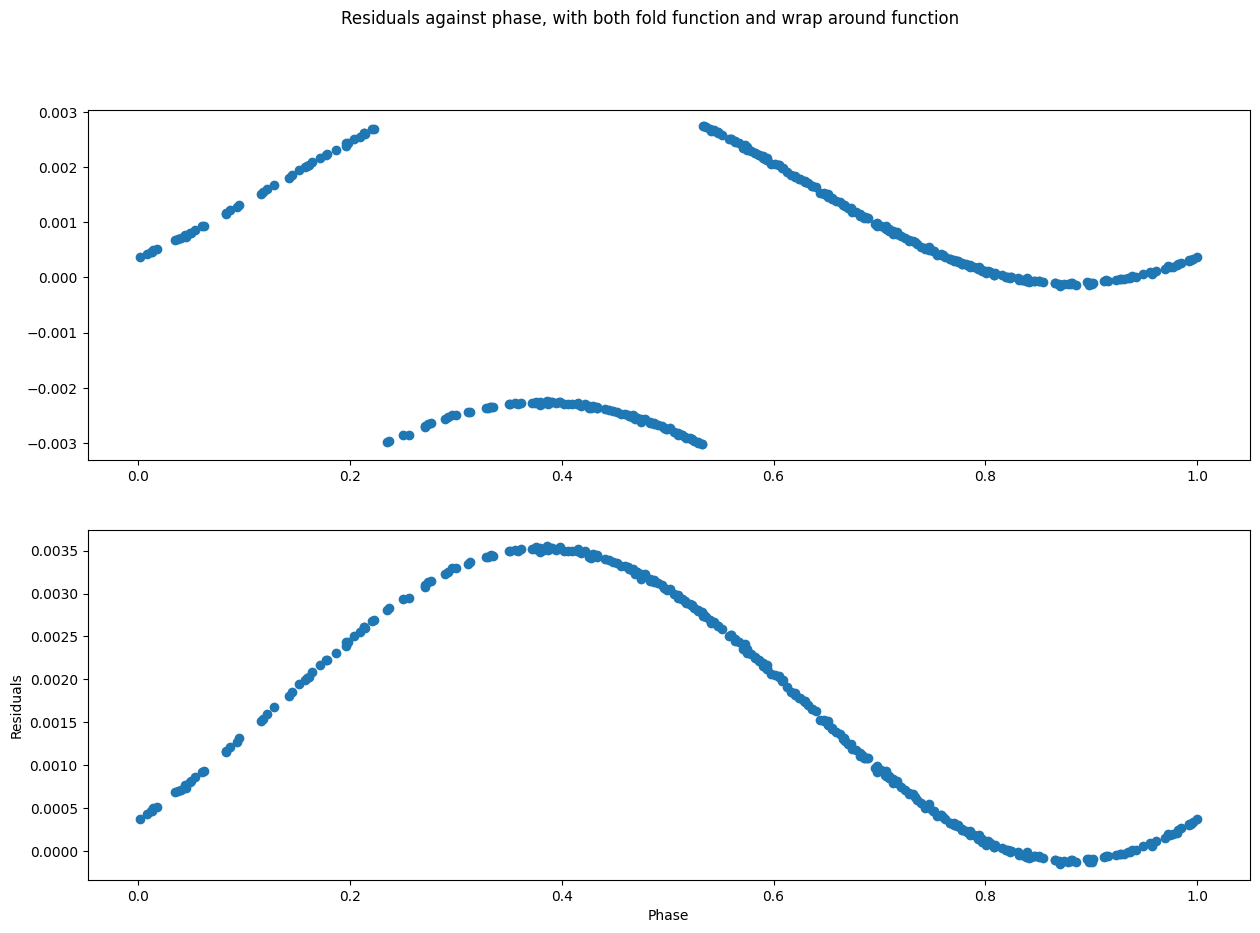

In [ ]:
## Showing the orbital phase of the planet from the data ##

psr = T.tempopulsar(parfile='1208890supporting - Copy.par',timfile="1208890supporting.tim")

def wrap_around(residual, period):
    return np.where( residual < -0.002, residual + period, residual)            ## Timing model correction to account for pulse arriving early for current pulse rather than late for the last one
def fold(time, period, origo=0.0):
    return (((time - origo)/period) % 1.)                                       ## Function used for light curves to plot points based on position fraction in phase

print(psr['F0'])
period = 1/172.70704460192937908

fig, (ax1, ax2) = plt.subplots(2, figsize = (15,10))
fig.suptitle("Residuals against phase, with both fold function and wrap around function")

ax1.scatter(fold(psr.toas(),0.09070629),psr.residuals())                        ## Showing folded data points
plt.xlabel("Phase")
plt.ylabel("Residuals")

ax2.scatter(fold(psr.toas(),0.09070629),wrap_around(psr.residuals(),period))    ## SHowing one orbital phase of the planet
plt.xlabel("Phase")
plt.ylabel("Residuals")

plt.show()

---
#### **Optimising to find the period** ####

* Attempting for one day
* Least squares fit - more accuarate

 The period of the planet is 0.09099972099277319  +/- 0.00014969023177489893days which is 2.1839933038265564 hours


Text(0, 0.5, 'Residual')

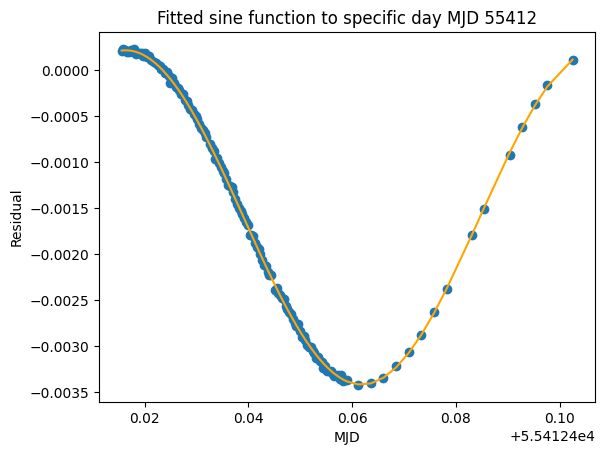

In [ ]:
psr = T.tempopulsar(parfile='1208890supporting - Copy.par',timfile="1208890supporting - Copy.tim")

def sine_function(t,a,b,c,d):
    return a * np.sin( 2 * (np.pi / b) * t + c) + d

def wrap_around2(residual, period):
    return np.where( residual > 0.002, residual - period, residual)    ## fliped around as moedel predicts differently

period = 1/172.70704460192937908

np.argmax(wrap_around2(psr.residuals(),period))
np.argmin(wrap_around2(psr.residuals(),period))


amplitude = (psr.residuals()[7] - psr.residuals()[121] )/2               ## estiating the amplitude by average of highest - lowest / 2

initial_guesses = [-0.0010680050609636948947, 0.091, 0.04, -0.0015]

parameters, covariance = curve_fit(sine_function,psr.toas(),wrap_around2(psr.residuals(),period), p0 =initial_guesses)
SE = np.sqrt(np.diag(covariance))
SE_B = SE[1]

fit_a = parameters[0]
fit_b = parameters[1]
fit_c = parameters[2]
fit_d = parameters[3]
print(f' The period of the planet is {fit_b}  +/- {SE_B}days which is {fit_b * 24} hours')

fitting = sine_function(psr.toas(),fit_a,fit_b,fit_c,fit_d)
plt.scatter(psr.toas(),wrap_around2(psr.residuals(),period))
plt.plot(psr.toas(),fitting, color = 'orange')
plt.title("Fitted sine function to specific day MJD 55412")
plt.xlabel("MJD")
plt.ylabel("Residual")

<ipython-input-3-9741ec6f81c6>:15: OptimizeWarning: Covariance of the parameters could not be estimated
  params, params_covariance = optimize.curve_fit(test_func, psr1.toas()[i], wrap_around(psr1.residuals()[i],(1/172.7070446)),


Text(0.5, 1.0, 'J1719-1438 residuals with attempted fit')

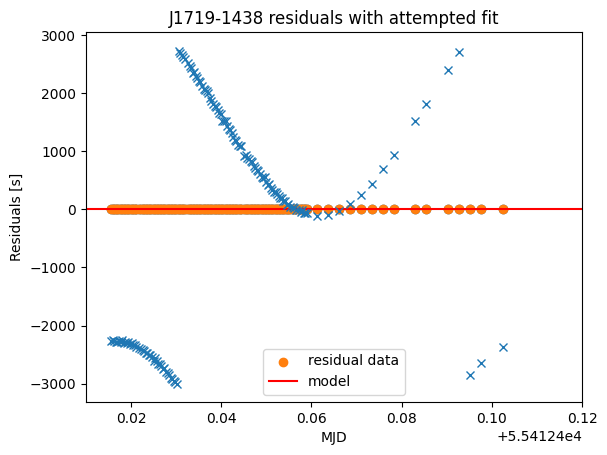

In [ ]:
def wrap_around(residual, period):
  return np.where(residual>0.002,residual-period,residual)

psr1 = T.tempopulsar(parfile='1208890supporting - Copy.par',timfile="1208890supporting.tim")
LP.plotres(psr1)
i = np.argsort(psr1.toas())
plt.scatter(psr1.toas()[i],wrap_around(psr1.residuals()[i],(1/172.70704460192937908)));
#plt.xlim(55400,55420)

def test_func(x,a,b,c,d):
  return (a*(np.sin(((2*np.pi)/b)*x + c))+d)

from scipy import optimize

params, params_covariance = optimize.curve_fit(test_func, psr1.toas()[i], wrap_around(psr1.residuals()[i],(1/172.70704460192937908)),
                                               p0=[0.0018, 0.09,0,0.0018])
i = np.argsort(psr1.toas())
plt.scatter(psr1.toas()[i],wrap_around(psr1.residuals()[i],(1/172.70704460192937908)),label = "residual data");
X = np.linspace(55200,55600,100000)

Y=test_func(X,params[0],params[1],params[2],params[3])
#print(X)
#print(Y)
plt.plot(X,Y,color='red',label='model')
plt.legend()
plt.xlim(55412.41,55412.52)
plt.xlabel("MJD")
plt.ylabel("Residuals [s]")
plt.title("J1719-1438 residuals with attempted fit")

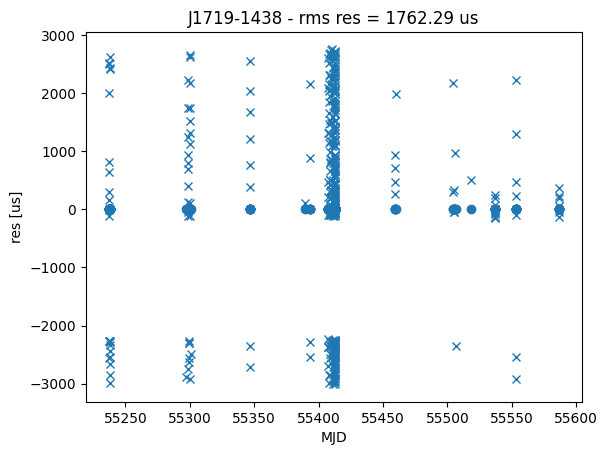

In [ ]:
def wrap_around(residual, period):
  return np.where(residual>0.002,residual-period,residual)

psr2 = T.tempopulsar(parfile='1208890supporting - Copy.par',timfile="1208890supporting.tim")
LP.plotres(psr2)
i = np.argsort(psr2.toas())
plt.scatter(psr2.toas()[i],wrap_around(psr2.residuals()[i],(1/172.7070446)));

**Better period:**


In [ ]:
psr1 = T.tempopulsar(parfile='1208890supporting - Copy.par',timfile="1208890supporting.tim")
i = np.argsort(psr1.toas())
def fold(time, period, origo=0.0, shift=0.5):
    return (((time - origo)/period + shift) % 1.)-0.5
def wrap_around(residual,period):
    return np.where(residual<-0.002,residual + period,residual)
def test_func(x,a,c,d):
    return (a*(np.sin((2*np.pi)*x + c))+d)

from scipy import optimize
def least_squares(x,y,ModelAmp,ModelPhase,ModelOffset,error):
    return (((y - (test_func(x,ModelAmp,ModelPhase,ModelOffset)))**2)/(error**2))


0.09070629699999931
773.97849892990240966


Text(0.5, 1.0, 'Residuals against phase for most optimal period')

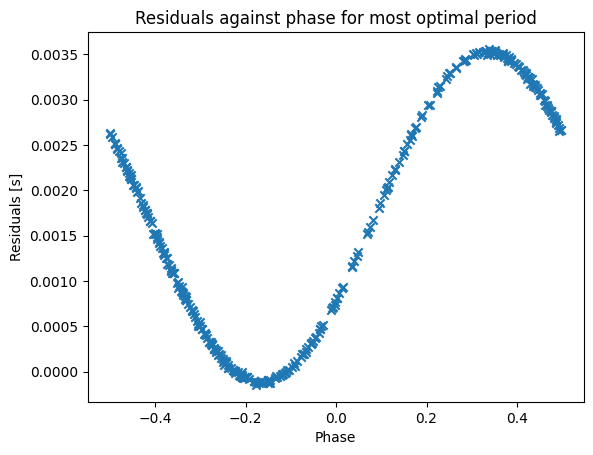

In [ ]:
n = 0.090705
N = 0.09071
square = 10000000000000000
Best_n = 0
Squares = []
while n <= N:
  new_square = 0
  X = fold(psr1.toas()[i],n)
  Y = wrap_around(psr1.residuals()[i],1/172.70704460192937908)
  Yerr = 1e-6*psr1.toaerrs[i]
  params, params_covariance = optimize.curve_fit(test_func, fold(psr1.toas()[i],0.090706), wrap_around(psr1.residuals()[i],(1/172.70704460192937908))
                                              ,p0=[0.0018,-0.1,0.0018])
  for each in range(len(X)):
    new_square+=least_squares(X[each],Y[each],params[0],params[1],params[2],Yerr[each])
  if new_square < square:
    square = new_square
    Best_n = n
    ModelAmp = params[0]
    ModelPhase = params[1]
    ModelOffset = params[2]
  n+=0.000000001
  Squares.append(new_square)
print(Best_n)
print(square)
plt.scatter(fold(psr1.toas()[i],Best_n),wrap_around(psr1.residuals()[i],0.005790151770038619), marker = "x")
plt.xlabel("Phase")
plt.ylabel("Residuals [s]")
plt.title("Residuals against phase for most optimal period")

In [ ]:
Reduced_Square = square/(len(psr1.toas()[i])-4)
print(Reduced_Square)

2.2831224157224259872


(0.0907062, 0.0907064)

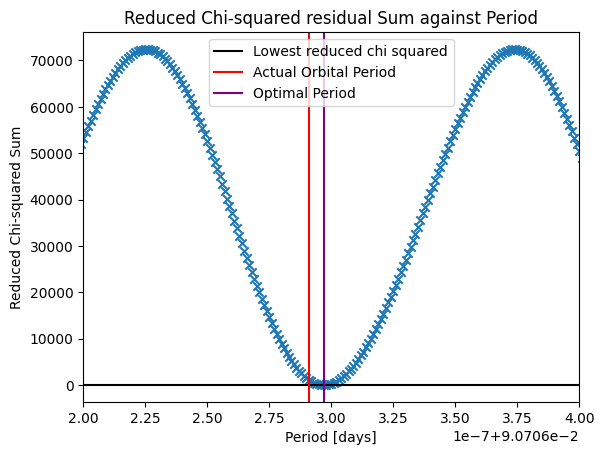

In [ ]:
Squares = np.array(Squares)

Reduced_Squares = Squares/(len(psr1.toas()[i])-4)

X = np.linspace(0.090705,0.09071,len(Reduced_Squares))
plt.axhline(Reduced_Square,color='black', label = 'Lowest reduced chi squared')
plt.axvline(0.090706291234533751382,color='red', label = 'Actual Orbital Period')
plt.axvline(Best_n,color='purple', label = 'Optimal Period')


plt.scatter(X,Reduced_Squares,marker = "x")
plt.xlabel("Period [days]")
plt.ylabel("Reduced Chi-squared Sum")
plt.title("Reduced Chi-squared residual Sum against Period")
plt.legend()
plt.xlim(0.0907062,0.0907064)
#plt.ylim(0,10000)
#plt.grid()

[ 0.00182011  0.09070628 -1.31880724  0.00170618]
[3.14621787e-05 1.42545087e-08 6.05467408e-01 9.19176744e-07]
0.09070627837842128 1.4254508745889851e-08


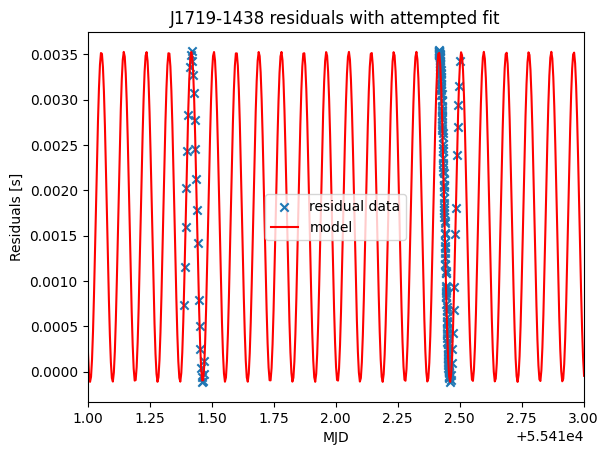

In [ ]:
def test_func(x,a,b,c,d):
  return (a*(np.sin(((2*np.pi)/b)*x + c))+d)

from scipy import optimize

params, params_covariance = optimize.curve_fit(test_func, psr1.toas()[i], wrap_around(psr1.residuals()[i],(1/172.70704460192937908)),
                                               p0=[ModelAmp,Best_n,0,ModelOffset])



i = np.argsort(psr1.toas())
plt.scatter(psr1.toas()[i],wrap_around(psr1.residuals()[i],(1/172.70704460192937908)),label = "residual data", marker = "x");
#plt.xlim(55400,55420
X = np.linspace(55200,55600,100000)

Y=test_func(X,params[0],params[1],params[2],params[3])
#print(X)
#print(Y)
plt.plot(X,Y,color='red',label='model')
plt.legend()
plt.xlim(55411,55413)
plt.xlabel("MJD")
plt.ylabel("Residuals [s]")
plt.title("J1719-1438 residuals with attempted fit")
print(params)
SE = np.sqrt(np.diag(params_covariance))
SE_b = SE[1]
print(SE)
print(params[1], SE_b)

In [ ]:
import numpy as np

P_B = 0.09070629123453375138
P_B_error = 8.6881046267399996885e-09

PB =  0.09070627837842128
PB_error = 1.4254508745889851e-08

sd3 = abs(PB - P_B) / np.sqrt(PB_error**2 + P_B_error**2)
print(f"Our value had a statistical distance,  sigma = {sd3}")

Our value had a statistical distance,  sigma = 0.7701251312710264


---
#### **Derivation of Pulsar Parameters and Errors!** ####

Most if not all derivations and estimations are found from this website about [Pulsars](https://www.cv.nrao.edu/~sransom/web/Ch6.html)

**Key thing** about this is that the calculations assume a cannonical pulsar:
* Radius, R = 10 km
* Mass = 1.4 $M_⊙$
* so moment of inertia is ~ $10^{45}$ g m^2

I calculated some of the limits of the values but we don't use them as its not accurate to the valeus in the paper so they must've done the same. I have done the following values (only 2, 3, 4a aren't in the paper):

* Period and Period Derivative
* Maximum Radius of the pulsar
* Moment of Inertia
* Rotational Energy + Spin Down Lumniosity
* Surface Magnetic Field
* Characteristic Age
* Dispersion Measure

In [ ]:
## Finding some values
print(psr1['F0'])
print(psr1['F1'])

f = 172.70704460192937908                                           ## Defining the Frequency
f_error = 1.9088425373999999946e-10

fdot = -2.1958832200264405067e-16                                   ## Defining the frequency derivative
fdot_error = 1.3410010308008839195e-17

P = 1/f                                                             ## Calculating the period
P_error = P * f_error / f                                           ## Calculating the period error

Pdot = -fdot /f**2                                                  ## Calculating the period derivative
Pdot_error = np.sqrt((1 / f**2 * fdot_error)**2
                        + (2 * fdot / f**3)**2)                     ## calculating pdot error

print(f"The pulsar has a period of {P} +/- {P_error:.2g} s " )
print(f"The pulsar has a period derivative of {Pdot:.2g} +/- {Pdot_error:.2g} s/s")


tempo2 parameter F0 (fitted): np.longdouble('172.70704460192937908') +/- np.longdouble('1.9088425373999999946e-10')
tempo2 parameter F1 (fitted): np.longdouble('-2.1958832200264405067e-16') +/- np.longdouble('1.3410010308008839195e-17')
The pulsar has a period of 0.005790151770038619 +/- 6.4e-15 s 
The pulsar has a period derivative of 7.4e-21 +/- 4.6e-22 s/s


In [ ]:
## Maximum Radius for our pulsar
G = 6.6743e-11
G_error = 1.5e-15

M = 1.4 * 1.988409870698051e+30
M_error = 1.4 * 4.468805426856864e+25

a = 4 * np.pi**2

R_max = (G * M * P**2 / a)**(1/3)
Par_diff = (1/3) * (G * M * P**2 / a) ** (-2/3)
R_max_error = np.sqrt( (Par_diff * (M * P**2/a) * G_error)**2
                      + (Par_diff * (G* P**2/a) * M_error)**2
                      + (Par_diff * (2*G*M*P/a) * P_error)**2)

print(f"The maximum radius of the pulsar is {R_max:.2g} +/- {R_max_error:.2f} m or with better units {R_max/1000:.2g} +/- {R_max_error/1000:.2g} km")

The maximum radius of the pulsar is 5.4e+04 +/- 0.57 m or with better units 54 +/- 0.00057 km


In [ ]:
## Moment of Inertia for our pulsar
R = 1e4         ## Assume a cannonical pulsar R = 10km and Mass is 1.4 Solar masses
I =  2 * M * R**2 / 5

I_error = (2 / 5 * R**2 * M_error)

print(f"The moment of inertia of the pulsar is {I} +/- {I_error} kg m^2")

The moment of inertia of the pulsar is 1.1135095275909085e+38 +/- 2.5025310390398435e+33 kg m^2


In [ ]:
## Rotational kintic Energy

E = 2 * np.pi**2 * I / P**2
E_error = ((2 * np.pi**2 * I_error/ P**2 )**2 + (4 * np.pi**2 * I * P_error/ P**3)**2)**.5

print(f"The Rotational Energy of our pulsar is {E} +/- {E_error} Joules")

The Rotational Energy of our pulsar is 6.556073041581962e+43 +/- 1.4734293577413345e+39 Joules


In [ ]:
### Spin Down Luminosity
L_sun = 3.828e26
L_sun_error = 0
spin_down_L = (4 * np.pi**2 * I * Pdot/ P**3)/(L_sun)

spin_down_L_error = 4* np.pi**2 / L_sun * ((Pdot*P**(-3)*I_error)**2
                                    + (I * P**(-3)*Pdot_error)**2
                                    + (3 * I * Pdot * P**(-4) * P_error)**2 )**.5


L_p = 0.40
L_error_p = 0.04

sd = abs(L_p - spin_down_L) / np.sqrt(L_error_p**2 + spin_down_L_error**2)

print(f"The spin down luminosity of the pulsar is {spin_down_L:.2f} +/- {spin_down_L_error:.2f} solar luminosities")
print(f"Our value had a statistical distance, from the true value fo {L_p} +/- {L_error_p}, of sigma = {sd:.2f}")

The spin down luminosity of the pulsar is 0.44 +/- 0.03 solar luminosities
Our value had a statistical distance, from the true value fo 0.4 +/- 0.04, of sigma = 0.74


In [ ]:
## Esitimating the minimum surface magnetic field
c = 3e10             ## Speed of light in csg standard
c_error = 0
R = 1e6              ## Radius in same standard no error(taken as constant)

constant = (3 * c**3 * 10**45 / (8 * np.pi**2 * R**6))**.5
B_s = constant * (P * Pdot)**.5
B_s_error = constant * np.sqrt((0.5 * (P * Pdot)**(-0.5) * Pdot * P_error)**2 + (0.5 * (P * Pdot)**(-0.5) * P * Pdot_error)**2)

print(f' The minimum surface magnetic field of the pulsar B_s > {B_s:.2g} +/- {B_s_error:.2g} G')

 The minimum surface magnetic field of the pulsar B_s > 2.1e+08 +/- 6.5e+06 G


In [ ]:
## Estimating the characteristic age

char_age = P / (2 * Pdot * 60 * 60 * 24 * 365 )

char_age_error = 0.5 /( 60 * 60 * 24 * 365) * np.sqrt((P_error / Pdot)**2 + (Pdot_error * P / Pdot**2)**2)
print(f"The characteristic age of our pulsar is > {char_age} +/- {char_age_error} years or according to the paper t > {char_age/1e9} +/- {char_age_error/1e9} Gy )")

The characteristic age of our pulsar is > 12469935578.79638 +/- 775095536.3536611 years or according to the paper t > 12.46993557879638 +/- 0.775095536353661 Gy )


In [ ]:
## Estimating Dispersion Measure
DM = 36.766
DM_error = 0.002
e_D = 0.03       ### Assume this for something in the plane of the galactic disk

DispMea = DM / e_D * 1e-3
DispMea_error =   DM_error / e_D * 1e-3

print(f'The derived Disperion Measure for our pulsar is {DispMea} +/- {DispMea_error} kpc')

DispMea_P = 1.2
DispMea_P_error = 0.3

sd2 = abs(DispMea - DispMea_P) / np.sqrt(DispMea_error**2 + DispMea_P_error**2)

print(f"Our value had a statistical distance, from the true value fo {DispMea_P} +/- {DispMea_P_error}, of sigma = {sd2:.2f}")

The derived Disperion Measure for our pulsar is 1.2255333333333334 +/- 6.666666666666667e-05 kpc
Our value had a statistical distance, from the true value fo 1.2 +/- 0.3, of sigma = 0.09


---
#### **Derivation of Planet Parameters** ####

* Preliminary - using one day period

In [ ]:
##Preliminary, using one day period.
##Probably not necessary to include these calculations in your report but should definitely mention we did one day first and talk about the period we obtained so I kept them in here.
##Initial calculation to find the orbital radius r.

import numpy as np

P_b = 0.09099998539977734
T = P_b*24*60*60
G = 6.67430*(10**(-11))
M_s = (1.989*(10**30))
m_p = 1.4*(M_s)

r = (((T**2)*(G*m_p)/(4*(np.pi**2)))**(1/3))
r_au = r / 149597870700

print(f"Hence the orbital radius of the planet around PSR J1719-1438 is {r}m; dividing this by 1 astronomical unit we get the orbital radius as measured in au: {r_au}au")

Hence the orbital radius of the planet around PSR J1719-1438 is 662683736.0016546m; dividing this by 1 astronomical unit we get the orbital radius as measured in au: 0.004429767167813402au


In [ ]:
##Second calculation to find the mass of the companion m_c
##First function of mass equation returns a function of the mass, f(m_c)

apsini = 0.001819 * 299792458 ##Constant for respective pulsar - Semi-major axis X sin(inclination angle)

##inclination angle i is angle between view plane and plane of orbit

f_m_c1 = ((4*(np.pi**2))/G)*((apsini**3)/(T**2))
print(f"Hence the mass of the companion planet in kg is {f_m_c1}kg") ##f(m_c) in kg
m_c_solar = (f_m_c1 / M_s)
print(f"Dividing this by the mass of the Sun we obtain the function of the companion mass as {m_c_solar} solar masses") ##Returns it as a function of solar mass - to compare with Bailes value

Hence the mass of the companion planet in kg is 1.5516868826430117e+21kg
Dividing this by the mass of the Sun we obtain the function of the companion mass as 7.801341793076981e-10 solar masses


In [ ]:
##Second function of mass equation returns mass of companion

##Takes into account a couple of assumptions to reduce values
##We assume an edge on orbit - hence i = 90 degrees, sin i = 1
##Also assume m_c << m_p
##Results in simply f(m_c) = (m_c)^3 / (m_p)^2

f_m_c2 = (7.801341793076981*(10**(-10)))*(M_s) ##Function of mass from previous section
m_c = (((m_p)**2) * f_m_c2)**(1/3) ##Reduced second function of mass equation
print(f"Hence the mass of the companion planet is {m_c}kg")

m_J = 1.898*(10**27)
m_c_jup = m_c / m_J
print(f"The mass of the companion when we compare it to Jupiter is {m_c_jup} Jupiters")  ##In terms of Jupiter's mass to compare with NASA and Bailes - agrees with both

Hence the mass of the companion planet is 2.2914474860038377e+27kg
The mass of the companion when we compare it to Jupiter is 1.2072958303497565 Jupiters


*  Final - using the least squares fit period

In [ ]:
##Orbital radius of the companion planet

import numpy as np

P_b = 0.09070627837842128
oP_b = 1.4254508745889851e-08
T = P_b*24*60*60
oT = oP_b*24*60*60
G = 6.6743e-11
oG = 1.5e-15
M_s = 1.988409870698051e+30
oM_s = 4.468805426856864e+25
m_p = 1.4*(M_s)
om_p = 1.4 * 4.468805426856864e+25

n = 4*(np.pi**2)
k = (1/3)*((G*m_p*(T**2))/n)**(-2/3)

oa = ((k*((m_p*(T**2))/n)*oG)**2 + (k*((G*(T**2))/n)*om_p)**2 + (k*((2*G*m_p*T)/n)*oT)**2)**(1/2)

a = (((T**2)*G*m_p)/n)**(1/3)
a_au = a / 149597870691
oa_au = oa / 149597870691
print(f"Hence using Kepler's Third Law we calulate the orbital radius of the planet around PSR J1719-1438, a, as {a} +- {oa}m")
print(f"dividing this by 1 astronomical unit we get the orbital radius as measured in au: {a_au} +- {oa_au}au")

##NO ERROR ONLINE TO COMPARE THIS TO REGARDING STATISTICAL WEIGHT

Hence using Kepler's Third Law we calulate the orbital radius of the planet around PSR J1719-1438, a, as 661191667.1716859 +- 7005.318470750691m
dividing this by 1 astronomical unit we get the orbital radius as measured in au: 0.004419793303992957 +- 4.682766163978656e-08au


In [ ]:
##Companion mass derivation and comparing this to both the masses of the Sun and Jupiter.

from astropy import constants as const
apsini = 0.001819 * 299792458
oapsini = 0.000001 * 299792458
n = 4*(np.pi**2)

f_m_c = ((n/G)*(apsini**3))/(T**2)
of_m_c = n*(((oG*(apsini)**3)/(G**2*T**2))**2 + ((oT*(apsini)**3)/(G*T**3))**2 + ((oapsini*3*(apsini)**2)/(G*T**2))**2)**(1/2)
print(f"The function of the companion mass is equal to {f_m_c} +- {of_m_c}kg")

f_m_c_solar = ((n/G)*(apsini**3))/(T**2*M_s)
of_m_c_solar = n*(((oG*(apsini)**3)/(G**2*T**2*M_s))**2 + ((oT*(apsini)**3)/(G*T**3*M_s))**2 + ((oM_s*(apsini)**3)/(G*T**2*M_s**2))**2 + ((oapsini*3*(apsini)**2)/(M_s*G*T**2))**2)**(1/2)
print(f"Hence the function of the companion mass is equal to {f_m_c_solar} +- {of_m_c_solar} solar masses")

m_c = (m_p**2 * f_m_c)**(1/3)
l = (1/3)*(f_m_c*m_p**2)**(-2/3)
om_c = ((l*m_p**2*of_m_c)**2 + (l*2*f_m_c*m_p*om_p)**2)**(1/2)
print(f"Following through, the mass of the companion planet calculated via the derived period is {m_c} +- {om_c}kg")

m_c_solar = ((m_p**2 * f_m_c)**(1/3)) / M_s
l = (1/3)*(f_m_c*m_p**2)**(-2/3)
om_c_solar = ((l/M_s*m_p**2*of_m_c)**2 + (l/M_s*2*f_m_c*m_p*om_p)**2 + (m_c/M_s**2*oM_s)**2)**(1/2)
print(f"Therefore, the mass of the companion is {m_c_solar} +- {om_c_solar} solar masses")

m_J = 1.8981245973360505e+27
om_J = 4.26589589320839e+22
m_c_jup = m_c / m_J
l = (1/3)*(f_m_c*m_p**2)**(-2/3)
om_c_jup = ((l/m_J*m_p**2*of_m_c)**2 + (l/m_J*2*f_m_c*m_p*om_p)**2 + (m_c/m_J**2*om_J)**2)**(1/2)
print(f"When comparing this to Juipter it returns a mas of {m_c_jup} +- {om_c_jup} Jupiter masses")

##Can calculate the statistical distance of the function of mass using Bailles 2011 value of (7.85 +- 0.001)x10^-10 solar masses

Bailles_f_m_c = 7.85e-10
oBailles_f_m_c = 0.01e-10
statdist_f_m_c = np.abs(f_m_c_solar - Bailles_f_m_c) / np.sqrt(oBailles_f_m_c**2 + of_m_c_solar**2)
print(f"Hence the statistical distance on the inital function of mass calculation is {statdist_f_m_c} sigma")

The function of the companion mass is equal to 1.5617518789362587e+21 +- 2.575970668441709e+18kg
Hence the function of the companion mass is equal to 7.854275428576455e-10 +- 1.2956130523673456e-12 solar masses
Following through, the mass of the companion planet calculated via the derived period is 2.2959370499708493e+27 +- 1.2627832093679886e+24kg
Therefore, the mass of the companion is 0.0011546598534862623 +- 6.356018498399555e-07 solar masses
When comparing this to Juipter it returns a mas of 1.2095818436751278 +- 0.0006658345789467443 Jupiter masses
Hence the statistical distance on the inital function of mass calculation is 0.2612309650733126 sigma


In [ ]:
##Total orbital seperation of the binary

R_s = 695700000
b = 0.95*R_s

a_T = b*(m_p/(1.4*M_s))**(1/3)
v = (1/3)*b*(m_p/(1.4*M_s))**(-2/3)
oa_T = ((v*(1/(1.4*M_s))*om_p)**2 + (v*(m_p/(1.4*M_s**2))*oM_s)**2)**(1/2)
print(f"The total component seperation is {a_T} +- {oa_T}m")
a_p = a - a_T
oa_p = ((oa)**2 + (oa_T)**2)**(1/2)
print(f"Hence the orbital radius of the pulsar is {a_p} +- {oa_p}m")
print(a)
##One of the most compact radio pulsar binaries

The total component seperation is 660915000.0 +- 7002.044832984839m
Hence the orbital radius of the pulsar is 276667.17168593407 +- 9904.701849110375m
661191667.1716859


In [ ]:
## Roche Lobe radius
import numpy as np

# constants
Ms = 1.988e30
Rs = 696e6
Mp = 1.4*Ms
G = 6.673e-11
P = 0.09070627837773888
M = 2.295e27

def a_paper(Mp, Rs, Ms):
  a = 0.95*Rs*(Mp/(1.4*Ms))**(1/3)
  return a

def a_cal(Mp,G,P):
  T = P * 24*3600
  c = G/(4*(np.pi)**2)
  a_cube = c*(Mp)*T**2
  a = (a_cube)**(1/3)
  return a


def paper_roche(a):
  Mc = 1.15e-3 * Ms
  r = 0.462*a*(Mc/(Mc+Mp))**(1/3)
  return r

def cal_roche(a, Mc):
  r = 0.462*a*(Mc/(Mc+Mp))**(1/3)
  return r

paper_sep = a_paper(Mp, Rs, Ms)
A = a_cal(Mp, G, P)
r_paper = paper_roche(paper_sep)
r_cal = cal_roche(A, M)
print("a from paper =",paper_sep/1e3, "km, calculated A =",A/1e3,"km, r_paper=",r_paper/1e3,"km, and our value=",r_cal/1e3)

# Uncertainty on A
c = (G*Mp)/(4*(np.pi)**2)
Dp = 0.00000001
Dt = Dp * 24*3600
T = P * 24*3600
A = a_cal(Mp, G, P)
Da = c**(1/3) *(2*T)**(1/3)* Dt

# statistical distance
Statd = np.abs(paper_sep - A)/Da

print('In Km, a =',A/1e3,'uncertainty on A',Da/1e3)
print("statstical distance on A =",Statd)


#Uncertainty on the Mass
Dm = 1.26e24

#Uncertainty on Roche
def DR(a, Pa, M, Pm):
  DR = np.sqrt((Pa*a)**2 + (Pm*M)**2)
  return DR

def da(M, Mp):
  f = 0.462*(M/(M+Mp))**(1/3)
  return f

def dm(a, M, Mp):
  F = Mp/((M+Mp)**2) * ((M+Mp)/M)**(2/3)
  f = 1/3 * 0.462 * a * F
  return f

dr= DR(Da, da(M, Mp), Dm, dm(A,M,Mp))

# statistical distance
Statd = np.abs(r_paper - r_cal)/dr

print('In Km, a =',r_cal/1e3,'uncertainty on A',dr/1e3)
print("statstical distance on A =",Statd)

a from paper = 661200.0 km, calculated A = 661103.3054494642 km, r_paper= 28600.86865286972 km, and our value= 28637.03952856623
In Km, a = 661103.3054494642 uncertainty on A 36.23064280025637
statstical distance on A = 2.6688610265317694
In Km, a = 28637.03952856623 uncertainty on A 5.4646043519889735
statstical distance on A = 6.619120684070169


---
###**Bibliography**

[Lorimer (2008)](https://ui.adsabs.harvard.edu/abs/2008LRR....11....8L/abstract).

[Wolszczan and Frail 1992](https://ui.adsabs.harvard.edu/abs/1992Natur.355..145W/abstract)

[Konacki and Wolszczan 2003](https://ui.adsabs.harvard.edu/abs/2003ApJ...591L.147K/abstract)

[Konacki et.al 2000](https://iopscience.iop.org/article/10.1086/308206/meta)

[Wolszczan et.al 2000](https://iopscience.iop.org/article/10.1086/312872/meta)

[Bailes et.al 2011](https://www.science.org/doi/10.1126/science.1208890)

[Van den Heuvel 1992](https://www.nature.com/articles/356668b0) (how pulsar binary companions collapse into rings around the pulsar)

[Steven et. al 1992](https://academic.oup.com/mnras/article/254/1/19P/1013564?login=false) (More in depth +how those rings form the exoplanets)

[libstempo citation](https://ui.adsabs.harvard.edu/abs/2020ascl.soft02017V/abstract)

[SciPy citation](https://ui.adsabs.harvard.edu/abs/2025zndo..14593523G/abstract)

[Exoplanet database](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS)

[All the pulsar derivations](https://www.cv.nrao.edu/~sransom/web/Ch6.html)

[Cochran 1952 (Overview of unweighted chi-sqaured)](https://www.jstor.org/stable/2236678?saml_data=eyJpbnN0aXR1dGlvbklkcyI6WyIxMTI1NzY5Yi0xMDZmLTRjYzYtODY1ZS02ZTQ5M2MyZTNiN2MiXSwic2FtbFRva2VuIjoiNWNkYzc3ZTctYTBhZC00Y2Q2LThmMGQtY2NmNjRlZGFkZTQ5In0&seq=1)

[Pearson 1900 (initial discovery of chi-squared)](https://www.tandfonline.com/doi/abs/10.1080/14786440009463897)

[B. Paczynski 1971](https://www.annualreviews.org/content/journals/10.1146/annurev.aa.09.090171.001151)(Roche lobe equation)

[pulsar in a 53 minute orbit 2023](https://www.nature.com/articles/s41586-023-06308-w)(why it can be used as an upper limit in pg 962)

[Hewish et al. 1968](https://www.nature.com/articles/217709a0) (Discovery of pulsars)

[Gold 1968](https://www.nature.com/articles/218731a0) (Early proposition of rotating neutron star model)

[Pacini 1968](https://www.nature.com/articles/219145a0) (Proof that pulsars will slow down over time)

[Martin et al. 2016](https://iopscience.iop.org/article/10.3847/0004-637X/832/2/122/pdf) (Description of how pulsar planets form and why they are rare)

[ATNF pulsar catalougue for J1719-1438](https://www.atnf.csiro.au/research/pulsar/psrcat/proc_form.php?version=2.6.0&Name=Name&JName=JName&RAJ=RAJ&DecJ=DecJ&PMRA=PMRA&PMDec=PMDec&PX=PX&PosEpoch=PosEpoch&ELong=ELong&ELat=ELat&PMElong=PMElong&PMElat=PMElat&GL=GL&GB=GB&RAJD=RAJD&DecJD=DecJD&P0=P0&P1=P1&F0=F0&F1=F1&F2=F2&F3=F3&PEpoch=PEpoch&DM=DM&DM1=DM1&RM=RM&W50=W50&W10=W10&Units=Units&Tau_sc=Tau_sc&S400=S400&S1400=S1400&S2000=S2000&Binary=Binary&T0=T0&PB=PB&A1=A1&OM=OM&ECC=ECC&TASC=TASC&EPS1=EPS1&EPS2=EPS2&MinMass=MinMass&MedMass=MedMass&Dist=Dist&Dist_DM=Dist_DM&DMsinb=DMsinb&ZZ=ZZ&XX=XX&YY=YY&Assoc=Assoc&Survey=Survey&OSurvey=OSurvey&Date=Date&Type=Type&NGlt=NGlt&R_Lum=R_Lum&R_Lum14=R_Lum14&Age=Age&BSurf=BSurf&Edot=Edot&Edotd2=Edotd2&PMTot=PMTot&VTrans=VTrans&P1_i=P1_i&Age_i=Age_i&BSurf_i=BSurf_i&B_LC=B_LC&startUserDefined=true&sort_attr=jname&sort_order=asc&condition=&coords_unit=raj%2Fdecj&radius=&coords_1=&coords_2=&pulsar_names=J1719-1438&ephemeris=short&style=short+without+errors&no_value=*&fsize=3&table_submit=&x_axis=&x_scale=linear&y_axis=&y_scale=linear&state=query)(Pulsar paramters)